## Full-set classifier tuning (>70% target)

Use the cells below to train on **50k train / 10k test** functaset without overwriting `cifar10_cnn_classifier/`.

# CIFAR-10 Running Model Quick Eval

Use this notebook to evaluate a checkpoint while training is still in progress. It does three things without touching the full production artifacts:

1. Load the current `modSiren.pth` checkpoint and run SGD phi reconstruction diagnostics.
2. Create a small CIFAR-10 functaset subset with configurable train/test sizes.
3. Train a quick downstream classifier on that subset and report its best accuracy.
4. Run a configurable image-space PGD attack on that classifier (end-to-end through φ refitting).

All generated artifacts go under `runs/<SLUG>/quick_eval/<EVAL_NAME>/` so you do not overwrite full makesets, classifiers, or PGD outputs.

In [1]:
# 0. Configuration
# Edit this cell first, then run cells top-to-bottom.

import os
from pathlib import Path

# Pick the physical GPU before importing torch in the next cell.
CUDA_DEVICE_ID = 0
os.environ["CUDA_VISIBLE_DEVICES"] = str(CUDA_DEVICE_ID)

# Repo root: use the directory that contains SIREN.py (works from notebooks/).
REPO_ROOT = Path("/home/omarg/SIREN_Vista")
if not (REPO_ROOT / "SIREN.py").exists():
    _candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent]
    for _p in _candidates:
        if (_p / "SIREN.py").exists():
            REPO_ROOT = _p
            break
    else:
        raise FileNotFoundError(
            "Could not find SIREN.py. Set REPO_ROOT to your SIREN_Vista clone."
        )
DATA_ROOT = Path("/home/omarg/data")

# Change this to whichever checkpoint is currently being trained/evaluated.
#SLUG = "functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e277_inner3_moptsgd_adamphi3_lr1e-02_softlip_refvanilla_e277_scale0.90_lam1e-02_sine_and_readout_train50000_test10000"
#SLUG = "functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e12_inner3_moptsgd_adamphi3_lr1e-02_softlip_cifar_spatial_tiered_lam1e-02_sine_and_readout_train50000_test10000"

SLUG = "functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e12_inner3_moptsgd_adamphi3_lr1e-02_softlip_cifar_spatial_tiered_lam1e-02_sine_and_readout_train50000_test10000"
SLUG = "cifar10_spatial_warmvanilla_orth_sine_and_readout_auto_lam1e-3"
CKPT_PATH = REPO_ROOT / "model_cifar10" / SLUG / "modSiren.pth"

# Quick-eval artifacts are isolated here. Change EVAL_NAME to keep multiple runs.
EVAL_NAME = "quick_eval_train1000_test1000"
QUICK_ROOT = REPO_ROOT / "runs" / SLUG / "quick_eval" / EVAL_NAME
OVERWRITE_QUICK_EVAL = True

# Reconstruction diagnostic.
IMAGE_INDICES = [8138, 0, 1, 2, 3, 4, 5, 10, 20, 30]
SGD_LR = 0.01
SNAPSHOT_ITERS = [3, 5, 20, 50, 100, 200, 500, 1000]

# Small functaset subset sizes.
MAKESET_TRAIN_SIZE = 50000
MAKESET_TEST_SIZE = 10000
MAKESET_ITERS = 3
MAKESET_LR = 0.01
MAKESET_INNER_OPTIM = "sgd"

# Quick classifier settings. CNN is the spatial-functa head used in the recent runs.
CLASSIFIER_TYPE = "cnn"  # one of: "mlp", "cnn", "vit"
CLF_EPOCHS = 120
CLF_BATCH_SIZE = 256
CLF_LR = 0.001
CLF_DROPOUT = 0.1
CNN_WIDTH = 128
NORMALIZE_PHI = True

# Optional alternatives if you test MLP/ViT.
MLP_WIDTH = 512
MLP_DEPTH = 2
VIT_WIDTH = 128
VIT_FFW_WIDTH = 256
VIT_DEPTH = 12
VIT_HEADS = 16
VIT_NORMALIZING_FACTOR = 0.08

# PGD attack on the quick classifier (section 5).
PGD_NUM_IMAGES = 20
PGD_ITERS = 40
PGD_EPS = 8  # L_inf bound = PGD_EPS / 255
PGD_LR = 0.01
PGD_INNER_STEPS = MAKESET_ITERS  # match functaset / meta-training inner steps

print("Configured quick eval")
print("  checkpoint:", CKPT_PATH)
print("  quick root:", QUICK_ROOT)
print("  gpu:", CUDA_DEVICE_ID)
print("  subset train/test:", MAKESET_TRAIN_SIZE, MAKESET_TEST_SIZE)

Configured quick eval
  checkpoint: /home/omarg/SIREN_Vista/model_cifar10/cifar10_spatial_warmvanilla_orth_sine_and_readout_auto_lam1e-3/modSiren.pth
  quick root: /home/omarg/SIREN_Vista/runs/cifar10_spatial_warmvanilla_orth_sine_and_readout_auto_lam1e-3/quick_eval/quick_eval_train1000_test1000
  gpu: 0
  subset train/test: 50000 10000


In [2]:
# 1. Imports, model loader, and reconstruction helpers

import json
import math
import shutil
import subprocess
import sys
from types import SimpleNamespace

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as T
from IPython.display import display
from skimage.metrics import structural_similarity as skimage_ssim
from torchvision.datasets import CIFAR10

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import variants
from SIREN import (
    ModulatedFINER,
    ModulatedFourierLSA,
    ModulatedFourierSIREN,
    ModulatedSIREN,
    SpatialModulatedINR,
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch:", torch.__version__)
print("device:", DEVICE)
if DEVICE == "cuda":
    print("cuda:0:", torch.cuda.get_device_name(0))

CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]


def get_siren_freq(model_args, default=30.0):
    return float(model_args.get("freq", model_args.get("siren_freq", model_args.get("omega_0", default))))


def _variant_args_from_ckpt(ckpt):
    variant_args = ckpt.get("variant_args", {}) or {}
    return SimpleNamespace(
        variant=ckpt.get("variant", "vanilla"),
        soft_lip_cap=variant_args.get("soft_lip_cap", 1.0),
        soft_lip_lambda=variant_args.get("soft_lip_lambda", 1e-2),
        soft_lip_apply_to=variant_args.get("soft_lip_apply_to", "sine_and_readout"),
        soft_lip_power_iters=variant_args.get("soft_lip_power_iters", 1),
        soft_lip_skip_first=variant_args.get("soft_lip_skip_first", False),
        soft_lip_reference_checkpoint=variant_args.get("soft_lip_reference_checkpoint", None),
        soft_lip_reference_scale=variant_args.get("soft_lip_reference_scale", 0.90),
    )


def build_model_from_checkpoint(ckpt_path, device):
    ckpt_path = Path(ckpt_path)
    ckpt = torch.load(ckpt_path, map_location="cpu")
    model_args = ckpt["model_args"]
    state = ckpt.get("state_dict", {}) or {}
    inr_type = model_args.get("inr_type", "siren")
    if inr_type == "siren" and "fourier.B" in state:
        inr_type = "fourier_siren"

    hidden_dim = model_args.get("hidden_dim", 256)
    depth = model_args.get("depth", 6)
    mod_dim = model_args.get("mod_dim", 1024)
    height = model_args.get("height", 32)
    width = model_args.get("width", 32)
    out_features = model_args.get("out_features", 3)
    siren_freq = get_siren_freq(model_args)

    is_spatial = bool(model_args.get("spatial_modulation", False)) or bool(model_args.get("is_spatial", False))
    if is_spatial:
        model = SpatialModulatedINR(
            height=height,
            width=width,
            hidden_features=hidden_dim,
            num_layers=depth,
            latent_spatial_dim=model_args.get("latent_spatial_dim", 8),
            latent_dim=model_args.get("latent_dim", 16),
            base_inr_type=inr_type,
            spatial_interp=model_args.get("spatial_interp", "nearest"),
            use_local_coords=bool(model_args.get("use_local_coords", True)),
            modulation_type=model_args.get("modulation_type", "shift"),
            freq=siren_freq,
            device=device,
            out_features=out_features,
            fourier_num_freqs=model_args.get("fourier_num_freqs", 64),
            fourier_sigma=model_args.get("fourier_sigma", 10.0),
            fourier_include_input=bool(model_args.get("fourier_include_input", False)),
            first_bias_scale=model_args.get("finer_first_bias_scale", None),
            scale_req_grad=bool(model_args.get("finer_scale_req_grad", False)),
            lsa_num_harmonics=model_args.get("lsa_num_harmonics", 8),
            lsa_init_scale=model_args.get("lsa_init_scale", 1e-3),
            lsa_include_linear=bool(model_args.get("lsa_include_linear", True)),
        )
    elif inr_type == "fourier_siren":
        nf = model_args.get("fourier_num_freqs") or (int(state["fourier.B"].shape[0]) if "fourier.B" in state else 64)
        model = ModulatedFourierSIREN(
            height=height, width=width, hidden_features=hidden_dim, num_layers=depth,
            modul_features=mod_dim, device=device, out_features=out_features,
            fourier_num_freqs=nf, fourier_sigma=model_args.get("fourier_sigma", 10.0),
            fourier_include_input=bool(model_args.get("fourier_include_input", False)),
            freq=siren_freq,
        )
    elif inr_type == "fourier_lsa":
        nf = model_args.get("fourier_num_freqs") or (int(state["fourier.B"].shape[0]) if "fourier.B" in state else 64)
        model = ModulatedFourierLSA(
            height=height, width=width, hidden_features=hidden_dim, num_layers=depth,
            modul_features=mod_dim, device=device, out_features=out_features,
            fourier_num_freqs=nf, fourier_sigma=model_args.get("fourier_sigma", 10.0),
            fourier_include_input=bool(model_args.get("fourier_include_input", False)),
            lsa_num_harmonics=model_args.get("lsa_num_harmonics", 8),
            lsa_init_scale=model_args.get("lsa_init_scale", 1e-3),
            lsa_include_linear=bool(model_args.get("lsa_include_linear", True)),
        )
    elif inr_type == "finer":
        model = ModulatedFINER(
            height=height, width=width, hidden_features=hidden_dim, num_layers=depth,
            modul_features=mod_dim, device=device, out_features=out_features,
            freq=model_args.get("finer_freq", model_args.get("freq", siren_freq)),
            first_bias_scale=model_args.get("finer_first_bias_scale", 1.0),
            scale_req_grad=bool(model_args.get("finer_scale_req_grad", False)),
        )
    else:
        model = ModulatedSIREN(
            height=height, width=width, hidden_features=hidden_dim, num_layers=depth,
            modul_features=mod_dim, device=device, out_features=out_features, freq=siren_freq,
        )

    variant = ckpt.get("variant", "vanilla")
    model = variants.build(variant, model, _variant_args_from_ckpt(ckpt))
    model.load_state_dict(state)
    model.to(device).eval()
    for p in model.parameters():
        p.requires_grad_(False)
    return model, ckpt, model_args


model, ckpt, model_args = build_model_from_checkpoint(CKPT_PATH, DEVICE)
H, W, C = model_args["height"], model_args["width"], model_args["out_features"]
MOD_DIM = model_args["mod_dim"]

print("Loaded model")
print("  checkpoint:", CKPT_PATH)
print("  epoch:", ckpt.get("epoch"))
print("  loss:", ckpt.get("loss"))
print("  variant:", ckpt.get("variant"))
print("  model_name:", ckpt.get("model_name"))
print("  spatial:", getattr(model, "is_spatial", False), "phi_shape:", getattr(model, "phi_shape", None))


def psnr_from_mse(mse):
    return 10.0 * math.log10(1.0 / max(float(mse), 1e-12))


def tensor_flat_to_img_np(x_flat, h=32, w=32, c=3):
    return x_flat.detach().view(h, w, c).clamp(0, 1).cpu().numpy()


def compute_ssim_np(target_img, recon_img):
    return skimage_ssim(target_img, recon_img, channel_axis=-1, data_range=1.0)


def laplacian_edges(x_flat, h=32, w=32, c=3):
    img = x_flat.view(h, w, c).permute(2, 0, 1).unsqueeze(0)
    kernel = torch.tensor([[0.0, 1.0, 0.0], [1.0, -4.0, 1.0], [0.0, 1.0, 0.0]], device=img.device, dtype=img.dtype).view(1, 1, 3, 3)
    kernel = kernel.repeat(c, 1, 1, 1)
    return F.conv2d(img, kernel, padding=1, groups=c)


def edge_laplacian_mse(target_flat, recon_flat, h=32, w=32, c=3):
    return F.mse_loss(laplacian_edges(target_flat, h, w, c), laplacian_edges(recon_flat, h, w, c)).item()


def forward_with_phi(model, phi):
    return model(phi).view(model.height * model.width, model.out_features)


dataset = CIFAR10(root=str(DATA_ROOT), train=True, download=True, transform=T.ToTensor())
print("Loaded CIFAR-10 train set:", len(dataset))

torch: 2.0.1+cu117
device: cuda
cuda:0: NVIDIA GeForce RTX 2080 Ti
Loaded model
  checkpoint: /home/omarg/SIREN_Vista/model_cifar10/functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e12_inner3_moptsgd_adamphi3_lr1e-02_softlip_cifar_spatial_tiered_lam1e-02_sine_and_readout_train50000_test10000/modSiren.pth
  epoch: 57
  loss: 0.0019054602624840142
  variant: soft_lipschitz
  model_name: functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e12_inner3_moptsgd_adamphi3_lr1e-02_softlip_cifar_spatial_tiered_lam1e-02_sine_and_readout_train50000_test10000
  spatial: True phi_shape: (8, 8, 16)
Files already downloaded and verified
Loaded CIFAR-10 train set: 50000


[1/10] fitting image_idx=8138
[2/10] fitting image_idx=0
[3/10] fitting image_idx=1
[4/10] fitting image_idx=2
[5/10] fitting image_idx=3
[6/10] fitting image_idx=4
[7/10] fitting image_idx=5
[8/10] fitting image_idx=10
[9/10] fitting image_idx=20
[10/10] fitting image_idx=30


,image_idx,label,class_name,iters,mse,psnr,ssim,edge_laplacian_mse,phi_norm
0,8138,8,ship,3,0.001517,28.190535,0.908727,0.016079,0.065210
1,8138,8,ship,5,0.001351,28.694862,0.919874,0.015015,0.065541
2,8138,8,ship,20,0.001105,29.564417,0.929890,0.014419,0.067009
3,8138,8,ship,50,0.001051,29.783570,0.931563,0.014180,0.067679
4,8138,8,ship,100,0.000993,30.028745,0.934376,0.013506,0.068341
...,...,...,...,...,...,...,...,...,...
75,30,0,airplane,50,0.002152,26.671708,0.836621,0.028236,0.060003
76,30,0,airplane,100,0.002037,26.909789,0.844212,0.026976,0.061576
77,30,0,airplane,200,0.001872,27.276129,0.855566,0.025191,0.066033
78,30,0,airplane,500,0.001617,27.912561,0.874032,0.022598,0.081169


,iters,mse_mean,psnr_mean,psnr_median,ssim_mean,edge_laplacian_mse_mean,phi_norm_mean
0,3,0.002020,27.381238,27.460439,0.881275,0.024303,0.070264
1,5,0.001822,27.853887,27.998214,0.892801,0.023139,0.070533
2,20,0.001663,28.290509,28.674463,0.900681,0.022245,0.071309
3,50,0.001587,28.488472,28.887941,0.903764,0.021532,0.071890
4,100,0.001495,28.728559,29.123157,0.907884,0.020498,0.072959
5,200,0.001374,29.079329,29.491255,0.913611,0.019058,0.075842
6,500,0.001191,29.680711,30.146759,0.922899,0.016983,0.085750
7,1000,0.001069,30.132194,30.604610,0.929498,0.015677,0.099278


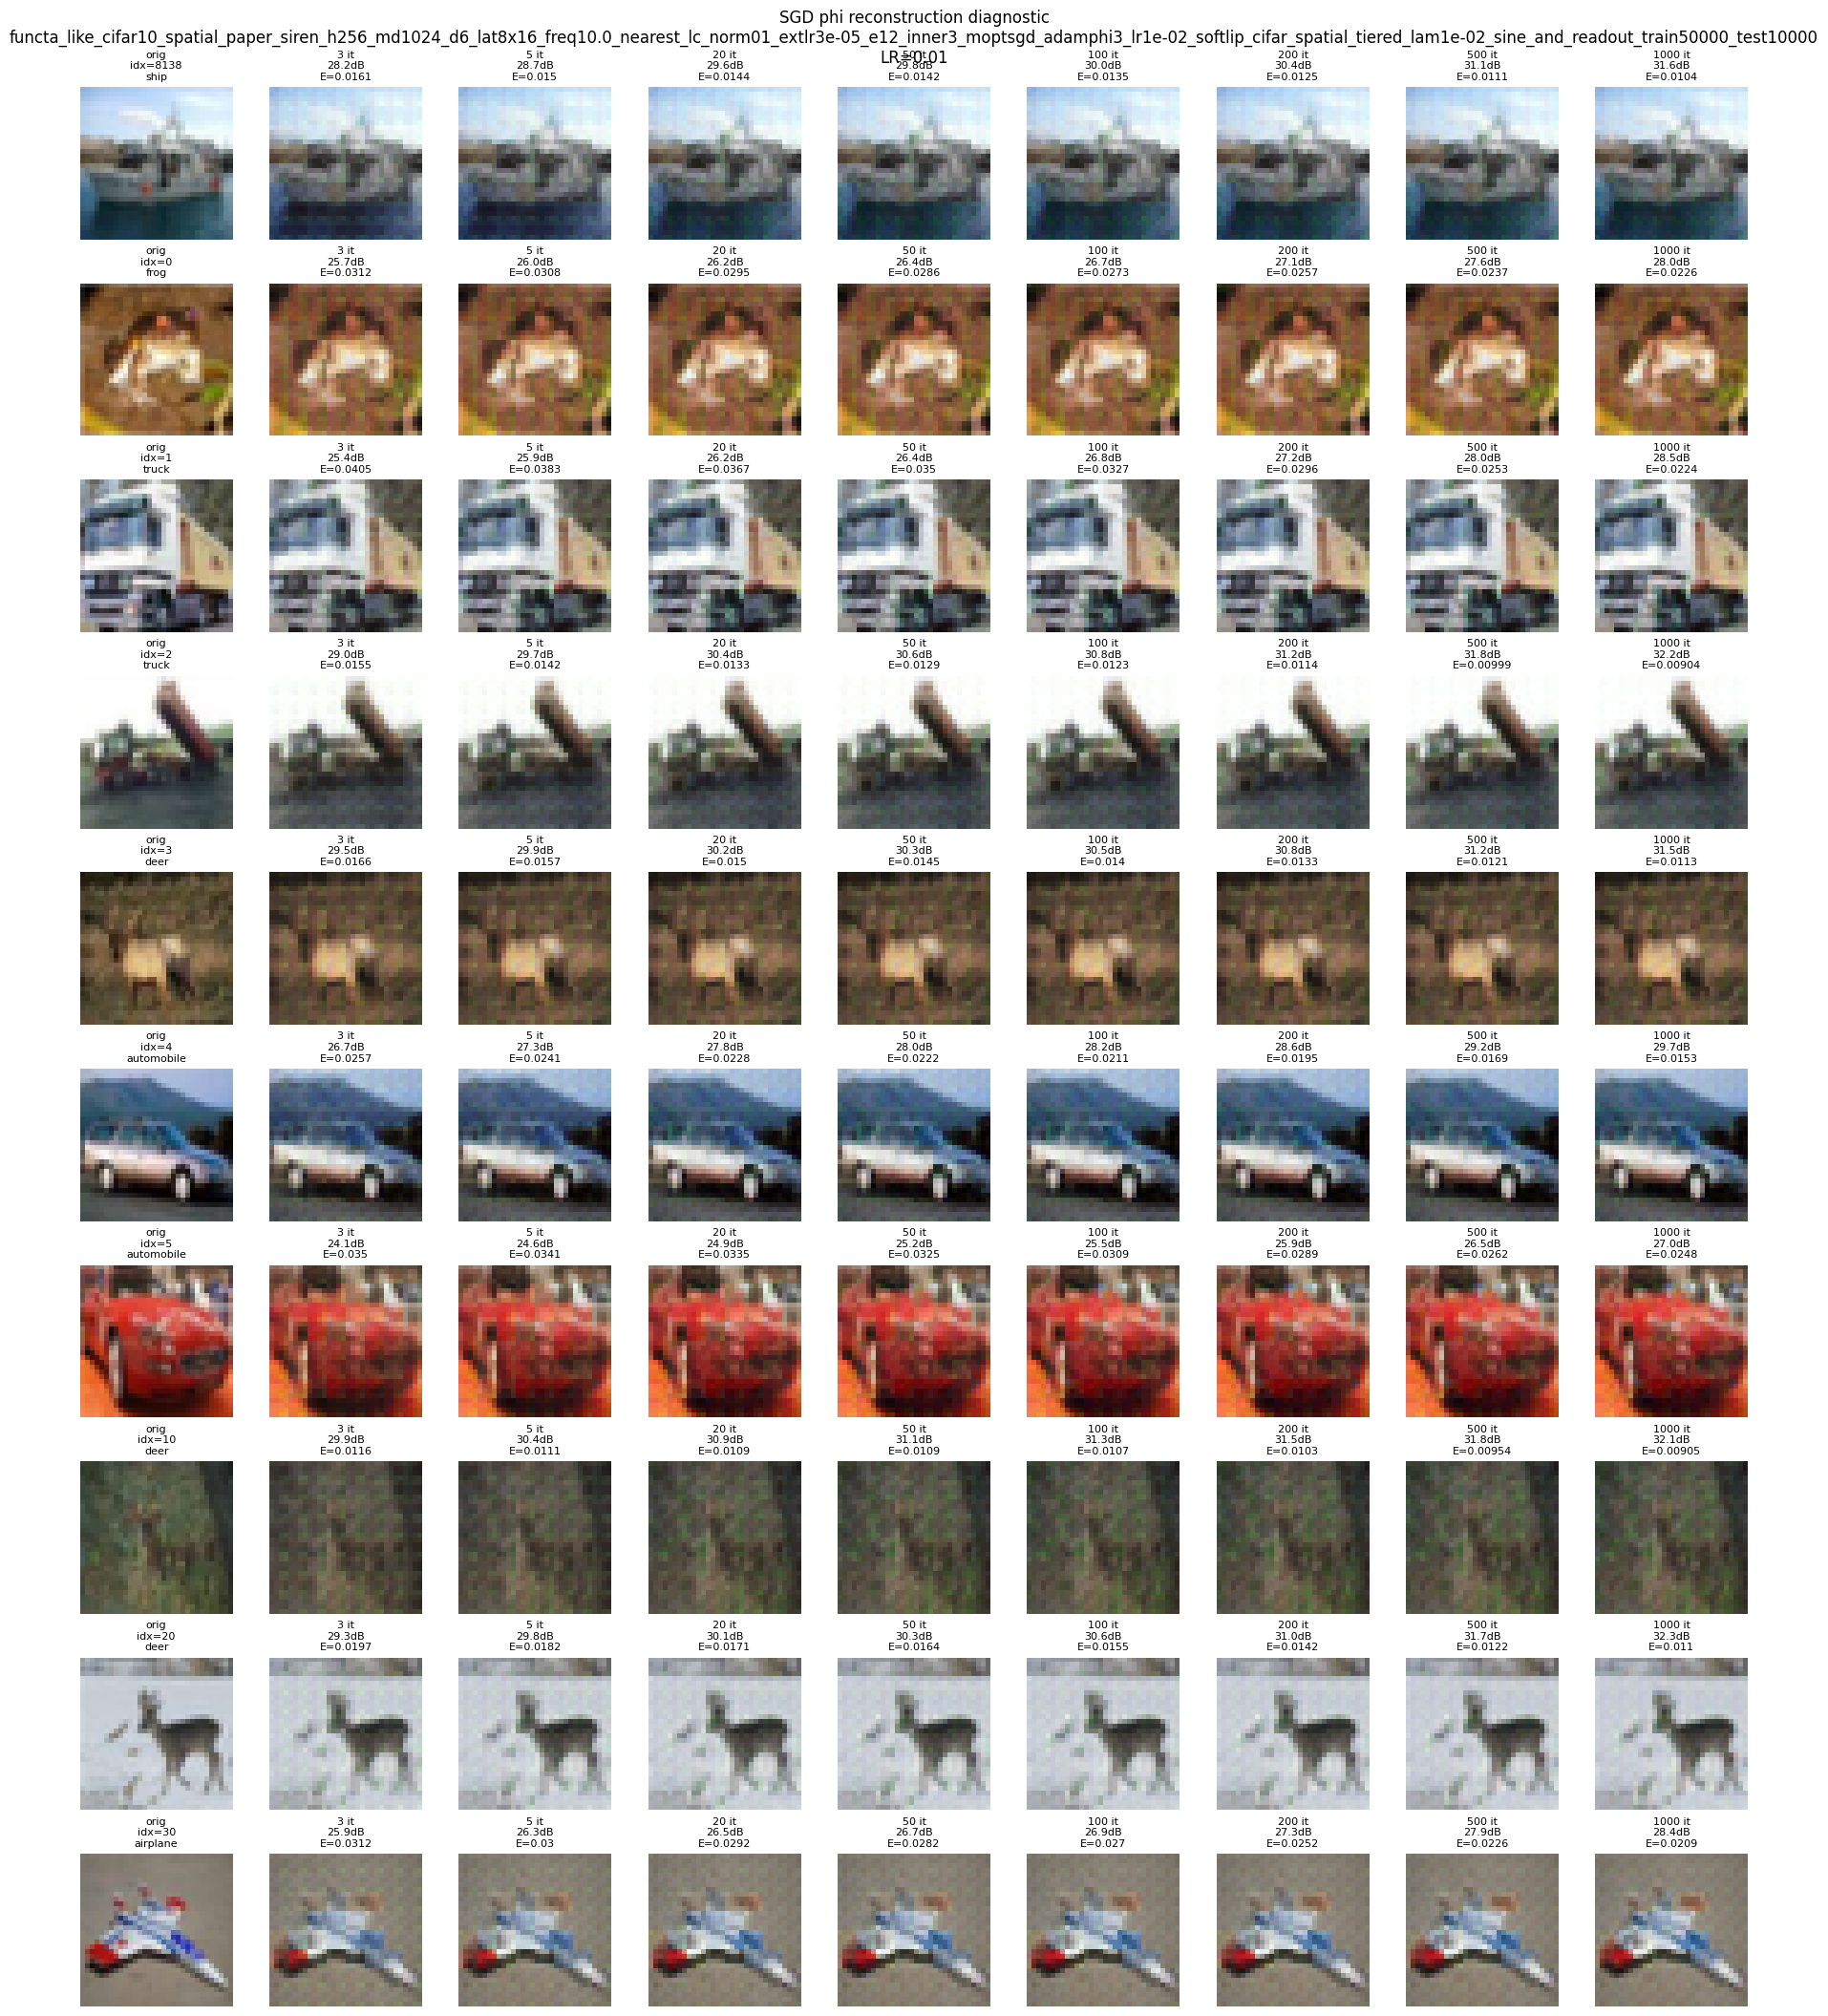

Saved:
  metrics: /home/omarg/SIREN_Vista/runs/functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e12_inner3_moptsgd_adamphi3_lr1e-02_softlip_cifar_spatial_tiered_lam1e-02_sine_and_readout_train50000_test10000/quick_eval/quick_eval_train1000_test1000/reconstruction/reconstruction_metrics.csv
  summary: /home/omarg/SIREN_Vista/runs/functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e12_inner3_moptsgd_adamphi3_lr1e-02_softlip_cifar_spatial_tiered_lam1e-02_sine_and_readout_train50000_test10000/quick_eval/quick_eval_train1000_test1000/reconstruction/reconstruction_summary.csv
  grid: /home/omarg/SIREN_Vista/runs/functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e12_inner3_moptsgd_adamphi3_lr1e-02_softlip_cifar_spatial_tiered_lam1e-02_sine_and_readout_train50000_test10000/quick_eval/quick_eval_train1000_test1000/reconstruction/sgd_phi_reconst

In [3]:
# 2. Reconstruction diagnostic on selected images

RECON_SAVE_DIR = QUICK_ROOT / "reconstruction"
RECON_SAVE_DIR.mkdir(parents=True, exist_ok=True)
MAX_ITERS = max(SNAPSHOT_ITERS)


def fit_single_image_with_sgd(image_idx):
    img_tensor, label = dataset[int(image_idx)]
    target_flat = img_tensor.permute(1, 2, 0).reshape(-1, C).to(DEVICE)
    target_np = img_tensor.permute(1, 2, 0).cpu().numpy()

    phi = model.init_phi(device=DEVICE).float().detach().requires_grad_(True)
    optimizer = optim.SGD([phi], lr=SGD_LR)
    snapshots = {}

    for step in range(1, MAX_ITERS + 1):
        optimizer.zero_grad()
        pred_flat = forward_with_phi(model, phi)
        loss = F.mse_loss(pred_flat, target_flat)
        loss.backward()
        optimizer.step()

        if step in SNAPSHOT_ITERS:
            with torch.no_grad():
                recon_flat = forward_with_phi(model, phi).clamp(0, 1)
                mse = F.mse_loss(recon_flat, target_flat).item()
                recon_np = tensor_flat_to_img_np(recon_flat, H, W, C)
                snapshots[step] = {
                    "recon_np": recon_np,
                    "mse": mse,
                    "psnr": psnr_from_mse(mse),
                    "ssim": compute_ssim_np(target_np, recon_np),
                    "edge_laplacian_mse": edge_laplacian_mse(target_flat, recon_flat, H, W, C),
                    "phi_norm": phi.detach().norm().item(),
                }

    return {
        "image_idx": int(image_idx),
        "label": int(label),
        "class_name": CIFAR10_CLASSES[int(label)],
        "target_np": target_np,
        "snapshots": snapshots,
    }


all_results = []
metric_rows = []
for k, image_idx in enumerate(IMAGE_INDICES):
    print(f"[{k + 1}/{len(IMAGE_INDICES)}] fitting image_idx={image_idx}")
    result = fit_single_image_with_sgd(image_idx)
    all_results.append(result)
    for step, snap in result["snapshots"].items():
        metric_rows.append({
            "image_idx": result["image_idx"],
            "label": result["label"],
            "class_name": result["class_name"],
            "iters": step,
            "mse": snap["mse"],
            "psnr": snap["psnr"],
            "ssim": snap["ssim"],
            "edge_laplacian_mse": snap["edge_laplacian_mse"],
            "phi_norm": snap["phi_norm"],
        })

metrics_df = pd.DataFrame(metric_rows)
display(metrics_df)
metrics_path = RECON_SAVE_DIR / "reconstruction_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

summary_df = metrics_df.groupby("iters").agg(
    mse_mean=("mse", "mean"),
    psnr_mean=("psnr", "mean"),
    psnr_median=("psnr", "median"),
    ssim_mean=("ssim", "mean"),
    edge_laplacian_mse_mean=("edge_laplacian_mse", "mean"),
    phi_norm_mean=("phi_norm", "mean"),
).reset_index()
display(summary_df)
summary_path = RECON_SAVE_DIR / "reconstruction_summary.csv"
summary_df.to_csv(summary_path, index=False)

n_rows = len(all_results)
n_cols = 1 + len(SNAPSHOT_ITERS)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.0 * n_cols, 2.15 * n_rows))
if n_rows == 1:
    axes = axes[None, :]

for r, result in enumerate(all_results):
    axes[r, 0].imshow(result["target_np"])
    axes[r, 0].set_title(f"orig\nidx={result['image_idx']}\n{result['class_name']}", fontsize=8)
    axes[r, 0].axis("off")
    for c_idx, step in enumerate(SNAPSHOT_ITERS, start=1):
        snap = result["snapshots"][step]
        axes[r, c_idx].imshow(snap["recon_np"])
        axes[r, c_idx].set_title(f"{step} it\n{snap['psnr']:.1f}dB\nE={snap['edge_laplacian_mse']:.3g}", fontsize=8)
        axes[r, c_idx].axis("off")

plt.suptitle(f"SGD phi reconstruction diagnostic\n{SLUG}\nLR={SGD_LR}", fontsize=12)
plt.tight_layout()
grid_path = RECON_SAVE_DIR / "sgd_phi_reconstruction_grid.png"
plt.savefig(grid_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:")
print("  metrics:", metrics_path)
print("  summary:", summary_path)
print("  grid:", grid_path)

In [4]:
# 3. Build a balanced small functaset subset from the current checkpoint
#
# MAKESET_TRAIN_SIZE and MAKESET_TEST_SIZE are total counts. This cell samples
# exactly total/10 images per CIFAR-10 class for train and test, so the quick
# classifier evaluation is not biased by class imbalance.

from collections import Counter, defaultdict
from torch.utils.data import DataLoader, Subset
from makeset import create_functaset

FUNCTASET_ROOT = QUICK_ROOT / "functaset"
QUICK_TRAIN_SPLIT_RATIO = globals().get("QUICK_TRAIN_SPLIT_RATIO", 0.8)
BALANCED_SUBSET_SEED = globals().get("BALANCED_SUBSET_SEED", 0)

if FUNCTASET_ROOT.exists():
    if OVERWRITE_QUICK_EVAL:
        shutil.rmtree(FUNCTASET_ROOT)
    else:
        raise RuntimeError(
            f"{FUNCTASET_ROOT} already exists. Set OVERWRITE_QUICK_EVAL=True "
            "or change EVAL_NAME to avoid overwriting."
        )

FUNCTASET_ROOT.mkdir(parents=True, exist_ok=True)


def _dataset_labels(ds):
    if hasattr(ds, "targets"):
        return np.asarray(ds.targets)
    if hasattr(ds, "labels"):
        return np.asarray(ds.labels)
    raise ValueError("Dataset does not expose .targets or .labels")


def balanced_indices(ds, total_size, seed=0, num_classes=10):
    if total_size % num_classes != 0:
        raise ValueError(
            f"total_size={total_size} must be divisible by {num_classes} "
            "for an exactly balanced CIFAR-10 subset."
        )
    per_class = total_size // num_classes
    labels = _dataset_labels(ds)
    rng = np.random.default_rng(seed)
    selected = []
    for cls in range(num_classes):
        cls_indices = np.flatnonzero(labels == cls)
        if len(cls_indices) < per_class:
            raise ValueError(f"Class {cls} has only {len(cls_indices)} samples; requested {per_class}.")
        selected.extend(rng.choice(cls_indices, size=per_class, replace=False).tolist())
    rng.shuffle(selected)
    return selected


def count_labels_for_indices(ds, indices):
    labels = _dataset_labels(ds)
    return Counter(int(labels[i]) for i in indices)


def balanced_train_val_split(functaset, train_ratio=0.8, seed=0, num_classes=10):
    by_label = defaultdict(list)
    for item in functaset:
        by_label[int(item["label"])].append(item)

    rng = np.random.default_rng(seed)
    train, val = [], []
    for cls in range(num_classes):
        items = list(by_label[cls])
        rng.shuffle(items)
        n_train = int(round(len(items) * train_ratio))
        train.extend(items[:n_train])
        val.extend(items[n_train:])

    rng.shuffle(train)
    rng.shuffle(val)
    return train, val


train_dataset = CIFAR10(root=str(DATA_ROOT), train=True, download=True, transform=T.ToTensor())
test_dataset = CIFAR10(root=str(DATA_ROOT), train=False, download=True, transform=T.ToTensor())

train_indices = balanced_indices(train_dataset, MAKESET_TRAIN_SIZE, seed=BALANCED_SUBSET_SEED)
test_indices = balanced_indices(test_dataset, MAKESET_TEST_SIZE, seed=BALANCED_SUBSET_SEED + 1)

print("Balanced subset indices selected")
print("  train total:", len(train_indices), "per-label:", dict(sorted(count_labels_for_indices(train_dataset, train_indices).items())))
print("  test total :", len(test_indices), "per-label:", dict(sorted(count_labels_for_indices(test_dataset, test_indices).items())))

train_loader = DataLoader(Subset(train_dataset, train_indices), batch_size=1, shuffle=False, num_workers=0, pin_memory=False)
test_loader = DataLoader(Subset(test_dataset, test_indices), batch_size=1, shuffle=False, num_workers=0, pin_memory=False)

if DEVICE != "cuda":
    raise RuntimeError("create_functaset currently expects CUDA. Set CUDA_VISIBLE_DEVICES and rerun on GPU.")

print("Creating balanced train+val functaset...")
full_train_functaset = create_functaset(
    model,
    train_loader,
    inner_steps=MAKESET_ITERS,
    inner_lr=MAKESET_LR,
    inner_optim=MAKESET_INNER_OPTIM,
)

train, val = balanced_train_val_split(
    full_train_functaset,
    train_ratio=QUICK_TRAIN_SPLIT_RATIO,
    seed=BALANCED_SUBSET_SEED,
)

print("Creating balanced test functaset...")
test = create_functaset(
    model,
    test_loader,
    inner_steps=MAKESET_ITERS,
    inner_lr=MAKESET_LR,
    inner_optim=MAKESET_INNER_OPTIM,
)

train_path = FUNCTASET_ROOT / f"{SLUG}_train.pkl"
val_path = FUNCTASET_ROOT / f"{SLUG}_val.pkl"
test_path = FUNCTASET_ROOT / f"{SLUG}_test.pkl"
train_all_path = FUNCTASET_ROOT / f"{SLUG}_train_all{MAKESET_TRAIN_SIZE}.pkl"
indices_path = FUNCTASET_ROOT / "balanced_indices.json"

joblib.dump(train, train_path)
joblib.dump(val, val_path)
joblib.dump(test, test_path)
joblib.dump(full_train_functaset, train_all_path)

with open(indices_path, "w") as f:
    json.dump(
        {
            "train_indices": [int(i) for i in train_indices],
            "test_indices": [int(i) for i in test_indices],
            "train_counts": dict(sorted(count_labels_for_indices(train_dataset, train_indices).items())),
            "test_counts": dict(sorted(count_labels_for_indices(test_dataset, test_indices).items())),
            "train_split_ratio": QUICK_TRAIN_SPLIT_RATIO,
            "seed": BALANCED_SUBSET_SEED,
        },
        f,
        indent=2,
    )

print("Functaset ready")
print("  train:", len(train), Counter(int(x["label"]) for x in train), train_path)
print("  val:", len(val), Counter(int(x["label"]) for x in val), val_path)
print("  train_all:", len(full_train_functaset), Counter(int(x["label"]) for x in full_train_functaset), train_all_path)
print("  test:", len(test), Counter(int(x["label"]) for x in test), test_path)
print("  indices:", indices_path)
print("  first modul shape:", full_train_functaset[0]["modul"].shape, "is_spatial:", full_train_functaset[0].get("is_spatial"))

Files already downloaded and verified
Files already downloaded and verified
Balanced subset indices selected
  train total: 50000 per-label: {0: 5000, 1: 5000, 2: 5000, 3: 5000, 4: 5000, 5: 5000, 6: 5000, 7: 5000, 8: 5000, 9: 5000}
  test total : 10000 per-label: {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000, 5: 1000, 6: 1000, 7: 1000, 8: 1000, 9: 1000}
Creating balanced train+val functaset...


MSE: 0.0022555245086550713:   0%|          | 4/50000 [00:00<22:32, 36.96it/s]

[makeset] first phi shape: (8, 8, 16) is_spatial: True


MSE: 0.003180365776643157: 100%|██████████| 50000/50000 [27:51<00:00, 29.91it/s]  


Creating balanced test functaset...


MSE: 0.008238039910793304:   0%|          | 5/10000 [00:00<03:54, 42.58it/s]

[makeset] first phi shape: (8, 8, 16) is_spatial: True


MSE: 0.0023473240435123444: 100%|██████████| 10000/10000 [05:36<00:00, 29.73it/s]


Functaset ready
  train: 40000 Counter({3: 4000, 8: 4000, 6: 4000, 7: 4000, 2: 4000, 9: 4000, 0: 4000, 5: 4000, 1: 4000, 4: 4000}) /home/omarg/SIREN_Vista/runs/functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e12_inner3_moptsgd_adamphi3_lr1e-02_softlip_cifar_spatial_tiered_lam1e-02_sine_and_readout_train50000_test10000/quick_eval/quick_eval_train1000_test1000/functaset/functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e12_inner3_moptsgd_adamphi3_lr1e-02_softlip_cifar_spatial_tiered_lam1e-02_sine_and_readout_train50000_test10000_train.pkl
  val: 10000 Counter({9: 1000, 1: 1000, 3: 1000, 2: 1000, 6: 1000, 5: 1000, 8: 1000, 4: 1000, 7: 1000, 0: 1000}) /home/omarg/SIREN_Vista/runs/functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e12_inner3_moptsgd_adamphi3_lr1e-02_softlip_cifar_spatial_tiered_lam1e-02_sine_and_readout_train50000_test1000

## 4. Train quick classifier

Train the downstream CNN/MLP/ViT on the functaset from section 3. Sets `CLF_DIR`, `best_path`, and `clf_ckpt` for section 5.

In [5]:
# 4. Train a quick classifier on the small functaset and report accuracy

if CLASSIFIER_TYPE == "mlp":
    CLF_DIR = QUICK_ROOT / "cifar10_classifier"
elif CLASSIFIER_TYPE == "cnn":
    CLF_DIR = QUICK_ROOT / "cifar10_cnn_classifier"
elif CLASSIFIER_TYPE == "vit":
    CLF_DIR = QUICK_ROOT / "cifar10_vit_classifier"
else:
    raise ValueError(f"Unknown CLASSIFIER_TYPE={CLASSIFIER_TYPE!r}")

if CLF_DIR.exists():
    if OVERWRITE_QUICK_EVAL:
        shutil.rmtree(CLF_DIR)
    else:
        raise RuntimeError(
            f"{CLF_DIR} already exists. Set OVERWRITE_QUICK_EVAL=True "
            "or change EVAL_NAME to avoid overwriting."
        )

cmd = [
    sys.executable,
    "train_classifier.py",
    "--dataset", "cifar10",
    "--classifier-type", CLASSIFIER_TYPE,
    "--functaset-path-train", str(train_all_path),
    "--functaset-path-test", str(test_path),
    "--latent-spatial-dim", str(model_args.get("latent_spatial_dim", 8)),
    "--latent-dim", str(model_args.get("latent_dim", 16)),
    "--mod-dim", str(MOD_DIM),
    "--dropout", str(CLF_DROPOUT),
    "--lr", str(CLF_LR),
    "--batch-size", str(CLF_BATCH_SIZE),
    "--num-epochs", str(CLF_EPOCHS),
    "--device", DEVICE,
    "--save-dir", str(CLF_DIR),
]

if CLASSIFIER_TYPE == "mlp":
    cmd += ["--cwidth", str(MLP_WIDTH), "--cdepth", str(MLP_DEPTH)]
elif CLASSIFIER_TYPE == "cnn":
    cmd += ["--cnn-width", str(CNN_WIDTH)]
elif CLASSIFIER_TYPE == "vit":
    cmd += [
        "--vit-width", str(VIT_WIDTH),
        "--vit-ffw-width", str(VIT_FFW_WIDTH),
        "--vit-depth", str(VIT_DEPTH),
        "--vit-heads", str(VIT_HEADS),
        "--vit-normalizing-factor", str(VIT_NORMALIZING_FACTOR),
    ]

if NORMALIZE_PHI:
    cmd += ["--normalize-phi"]

print("Running classifier command:")
print(" ".join(map(str, cmd)))
subprocess.run(cmd, cwd=REPO_ROOT, check=True)

best_path = CLF_DIR / "best_classifier.pth"
clf_ckpt = torch.load(best_path, map_location="cpu")
acc_path = CLF_DIR / "classifier_acc.npy"
acc = np.load(acc_path) if acc_path.exists() else None

print("Quick classifier result")
print("  checkpoint:", best_path)
print("  classifier_type:", clf_ckpt.get("classifier_type"))
print("  best epoch:", clf_ckpt.get("epoch"))
print("  best top-1 accuracy:", clf_ckpt.get("accuracy"))
if acc is not None:
    print("  final top-1:", float(acc[0][-1]))
    print("  final top-5:", float(acc[1][-1]))

summary_md = CLF_DIR / "quick_eval_summary.md"
lines = [
    "# Quick Classifier Evaluation Summary",
    "",
    f"- **model slug**: `{SLUG}`",
    f"- **checkpoint**: `{CKPT_PATH}`",
    f"- **quick root**: `{QUICK_ROOT}`",
    f"- **functaset train_all**: `{train_all_path}`",
    f"- **functaset test**: `{test_path}`",
    f"- **train subset size requested**: {MAKESET_TRAIN_SIZE}",
    f"- **test subset size requested**: {MAKESET_TEST_SIZE}",
    f"- **classifier type**: `{CLASSIFIER_TYPE}`",
    f"- **classifier checkpoint**: `{best_path}`",
    f"- **best epoch**: {clf_ckpt.get('epoch')}",
    f"- **best top-1 accuracy**: {clf_ckpt.get('accuracy')}",
]
if acc is not None:
    lines += [
        f"- **final top-1**: {float(acc[0][-1]):.4f}",
        f"- **final top-5**: {float(acc[1][-1]):.4f}",
    ]
lines.append("")
summary_md.write_text("\n".join(lines))
print("Wrote:", summary_md)

Running classifier command:
/home/omarg/miniforge3/envs/pss/bin/python train_classifier.py --dataset cifar10 --classifier-type cnn --functaset-path-train /home/omarg/SIREN_Vista/runs/functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e12_inner3_moptsgd_adamphi3_lr1e-02_softlip_cifar_spatial_tiered_lam1e-02_sine_and_readout_train50000_test10000/quick_eval/quick_eval_train1000_test1000/functaset/functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e12_inner3_moptsgd_adamphi3_lr1e-02_softlip_cifar_spatial_tiered_lam1e-02_sine_and_readout_train50000_test10000_train_all50000.pkl --functaset-path-test /home/omarg/SIREN_Vista/runs/functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e12_inner3_moptsgd_adamphi3_lr1e-02_softlip_cifar_spatial_tiered_lam1e-02_sine_and_readout_train50000_test10000/quick_eval/quick_eval_train1000_test1000/functaset/functa

[norm] computing phi stats: 100%|██████████| 196/196 [00:01<00:00, 165.07it/s]


[classifier] computed phi mean/std normalization stats


  0%|          | 0/40 [00:00<?, ?it/s]

epoch: 0, loss: 1.5270, train acc: 44.382%


...

epoch: 118, val accuracy: top1 70.96%, top5 97.26%


  0%|          | 0/40 [00:00<?, ?it/s]

epoch: 119, loss: 0.0025, train acc: 99.998%


100%|██████████| 40/40 [00:00<00:00, 80.13it/s]


epoch: 119, val accuracy: top1 70.93%, top5 97.27%
Best Accuracy: 71.20 % at epoch 65
Final global step: 23520
Quick classifier result
  checkpoint: /home/omarg/SIREN_Vista/runs/functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e12_inner3_moptsgd_adamphi3_lr1e-02_softlip_cifar_spatial_tiered_lam1e-02_sine_and_readout_train50000_test10000/quick_eval/quick_eval_train1000_test1000/cifar10_cnn_classifier/best_classifier.pth
  classifier_type: cnn
  best epoch: 65
  best top-1 accuracy: 71.2
  final top-1: 70.93
  final top-5: 97.27
Wrote: /home/omarg/SIREN_Vista/runs/functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e12_inner3_moptsgd_adamphi3_lr1e-02_softlip_cifar_spatial_tiered_lam1e-02_sine_and_readout_train50000_test10000/quick_eval/quick_eval_train1000_test1000/cifar10_cnn_classifier/quick_eval_summary.md


## 5. PGD attack on the notebook classifier

End-to-end **image-space** PGD on the classifier from **section 4** (`best_path` / `CLF_DIR`). Uses the backbone `model` from section 1.

Run section 4 immediately before this cell so `best_path` and `clf_ckpt` match the classifier you just trained.

In [6]:
# 5. PGD attack on the classifier trained in section 4 (uses best_path, CLF_DIR, clf_ckpt)

import torch.nn as nn
from torch.utils.data import DataLoader, Subset

from attacks.full_pgd_cifar10_spatial import (
    FullPGDCIFAR10Spatial,
    check_model_classifier_compat,
    load_classifier_checkpoint,
    run_attack,
)

# --- PGD knobs (override here or in the config cell) ---
PGD_NUM_IMAGES = int(globals().get("PGD_NUM_IMAGES", 20))
PGD_ITERS = int(globals().get("PGD_ITERS", 40))
PGD_EPS = int(globals().get("PGD_EPS", 8))  # L_inf = PGD_EPS / 255
PGD_LR = float(globals().get("PGD_LR", 0.01))
PGD_INNER_STEPS = int(globals().get("PGD_INNER_STEPS", MAKESET_ITERS))

for var in ("best_path", "CLF_DIR", "clf_ckpt"):
    if var not in globals():
        raise NameError(
            f"{var} is not defined. Run section 4 (train classifier) first."
        )

if not Path(best_path).exists():
    raise FileNotFoundError(
        f"Notebook classifier checkpoint not found: {best_path}\n"
        "Re-run section 4 to train/load the quick classifier."
    )

# Load from the exact checkpoint section 4 just wrote (not runs/<SLUG>/cifar10_cnn_classifier/).
classifier, clf_ckpt_loaded = load_classifier_checkpoint(str(best_path), DEVICE)
if clf_ckpt_loaded.get("accuracy") != clf_ckpt.get("accuracy"):
    print(
        "[warn] clf_ckpt accuracy differs from re-loaded checkpoint; "
        "using best_path on disk."
    )
check_model_classifier_compat(model, classifier)

attack_model = FullPGDCIFAR10Spatial(
    model,
    classifier,
    inner_steps=PGD_INNER_STEPS,
    inner_lr=MAKESET_LR,
    device=DEVICE,
).to(DEVICE)

test_dataset = CIFAR10(root=str(DATA_ROOT), train=False, download=True, transform=T.ToTensor())
if "test_indices" in globals():
    pgd_indices = list(test_indices)[:PGD_NUM_IMAGES]
else:
    pgd_indices = list(range(PGD_NUM_IMAGES))
pgd_loader = DataLoader(
    Subset(test_dataset, pgd_indices),
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

PGD_OUT_DIR = QUICK_ROOT / "pgd"
PGD_OUT_DIR.mkdir(parents=True, exist_ok=True)
pgd_json = PGD_OUT_DIR / f"eps{PGD_EPS}_steps{PGD_ITERS}_n{len(pgd_indices)}.json"

print("PGD configuration")
print("  notebook classifier (section 4):", best_path)
print("  CLF_DIR:", CLF_DIR)
print("  classifier acc (section 4):", clf_ckpt.get("accuracy"))
print("  backbone:", CKPT_PATH)
print("  num images:", len(pgd_indices))
print("  pgd iters:", PGD_ITERS)
print("  L_inf eps:", PGD_EPS / 255.0)
print("  pgd lr:", PGD_LR)
print("  inner steps / lr:", PGD_INNER_STEPS, MAKESET_LR)
print("  output:", pgd_json)

criterion = nn.CrossEntropyLoss().to(DEVICE)
pgd_results = run_attack(
    attack_model,
    pgd_loader,
    criterion,
    constraint=PGD_EPS / 255.0,
    pgd_iters=PGD_ITERS,
    pgd_lr=PGD_LR,
    device=DEVICE,
    max_samples=len(pgd_indices),
    output_json=str(pgd_json),
    model_slug=SLUG,
    classifier_type=getattr(classifier, "_clf_type", CLASSIFIER_TYPE),
)

pgd_results

Files already downloaded and verified
PGD configuration
  notebook classifier (section 4): /home/omarg/SIREN_Vista/runs/functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e12_inner3_moptsgd_adamphi3_lr1e-02_softlip_cifar_spatial_tiered_lam1e-02_sine_and_readout_train50000_test10000/quick_eval/quick_eval_train1000_test1000/cifar10_cnn_classifier/best_classifier.pth
  CLF_DIR: /home/omarg/SIREN_Vista/runs/functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e12_inner3_moptsgd_adamphi3_lr1e-02_softlip_cifar_spatial_tiered_lam1e-02_sine_and_readout_train50000_test10000/quick_eval/quick_eval_train1000_test1000/cifar10_cnn_classifier
  classifier acc (section 4): 71.2
  backbone: /home/omarg/SIREN_Vista/model_cifar10/functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e12_inner3_moptsgd_adamphi3_lr1e-02_softlip_cifar_spatial_tiered_lam1e-02_sine_a

eps=0.0314: n=1 clean=0.000 robust=0.000 robust|clean=0.000:   5%|▌         | 1/20 [00:02<00:56,  2.97s/it]

Clean MSE: 0.19642971456050873. Perturbation Final MSE: 0.05419103428721428


eps=0.0314: n=2 clean=0.000 robust=0.000 robust|clean=0.000:  10%|█         | 2/20 [00:05<00:45,  2.53s/it]

Clean MSE: 0.13557161390781403. Perturbation Final MSE: 0.024303950369358063


...

eps=0.0314: n=19 clean=0.421 robust=0.000 robust|clean=0.000:  95%|█████████▌| 19/20 [00:41<00:02,  2.16s/it]

Clean MSE: 0.05633228272199631. Perturbation Final MSE: 0.003175238845869899


eps=0.0314: n=20 clean=0.400 robust=0.000 robust|clean=0.000: 100%|██████████| 20/20 [00:43<00:00,  2.17s/it]

Clean MSE: 0.13265857100486755. Perturbation Final MSE: 0.022120729088783264

[final] eps=0.031373 n=20
[final]   clean correct           : 8/20  = 0.4000
[final]   robust correct (uncond.): 0/20  = 0.0000
[final]   robust|clean (condit.)  : 0/8  = 0.0000
[final] wrote /home/omarg/SIREN_Vista/runs/functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e12_inner3_moptsgd_adamphi3_lr1e-02_softlip_cifar_spatial_tiered_lam1e-02_sine_and_readout_train50000_test10000/quick_eval/quick_eval_train1000_test1000/pgd/eps8_steps40_n20.json


{'dataset': 'cifar10',
 'model_slug': 'functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e12_inner3_moptsgd_adamphi3_lr1e-02_softlip_cifar_spatial_tiered_lam1e-02_sine_and_readout_train50000_test10000',
 'classifier_type': 'cnn',
 'constraint': 0.03137254901960784,
 'pgd_iters': 40,
 'pgd_lr': 0.01,
 'n_samples': 20,
 'clean_correct': 8,
 'robust_correct_unconditional': 0,
 'both_correct': 0,
 'clean_acc': 0.4,
 'robust_acc': 0.0,
 'conditional_robust_acc': 0.0}